# **MÓDULO 14 - Exercício**
# Pré Processamento dos Dados - A primeira etapa Pré Modelagem

Para nossa atividade usaremos uma base de churn também, porém essa base não diz respeito a serviços bancários e sim serviços de internet, telefone e tv - Telecomunicação.

Vamos realizar aqui as etapas de limpeza e tratamento de dados vistos durante a aula, porém aplicados a essa base nova.

In [201]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [202]:
#Lembrem-se sempre de alterar a importação dos dados de acordo com o diretório de vocês.
df = pd.read_csv("CHURN_TELECON_MOD08_TAREFA.csv", delimiter=';')

df.head(10)

,customerID,Genero,Idoso,Casado,Dependents,Tempo_como_Cliente,PhoneService,Servico_Internet,Servico_Seguranca,Suporte_Tecnico,StreamingTV,Tipo_Contrato,PaymentMethod,Pagamento_Mensal,Total_Pago,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,DSL,No,No,No,Month-to-month,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,DSL,Yes,No,No,One year,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,DSL,Yes,No,No,Month-to-month,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,DSL,Yes,Yes,No,One year,Bank transfer (automatic),NaN,1840.75,No
4,9237-HQITU,NaN,0,No,No,2,Yes,Fiber optic,No,No,No,Month-to-month,Electronic check,NaN,151.65,Yes
5,9305-CDSKC,NaN,0,No,No,8,Yes,Fiber optic,No,No,Yes,Month-to-month,Electronic check,NaN,820.50,NaN
6,1452-KIOVK,NaN,0,No,Yes,22,Yes,Fiber optic,No,No,Yes,Month-to-month,Credit card (automatic),NaN,1949.40,NaN
7,6713-OKOMC,NaN,0,No,No,10,No,DSL,Yes,No,No,Month-to-month,Mailed check,NaN,301.90,NaN
8,7892-POOKP,NaN,0,Yes,No,28,Yes,Fiber optic,No,Yes,Yes,Month-to-month,Electronic check,NaN,3046.05,NaN
9,6388-TABGU,NaN,0,No,Yes,62,Yes,dsl,Yes,No,No,One year,Bank transfer (automatic),NaN,3487.95,NaN


Legenda dos dados:

*   **CustomerID** : Esse é o ID único de cada cliente nosso da rede de produtos de telecomunicação.

*   **Genero** : O genero dos nossos clientes.

*   **Idoso** : Se nosso cliente tem acima de 60 anos ou não. (Sim = 1 | Não = 0)

*   **Casado** : Se nosso cliente é casado ou não.

*   **Dependents** : Se cliente tem dependentes.

*   **Tempo_como_Cliente** : Tempo em meses que nosso cliente está com a nossa empresa.

*   **PhoneService** : Se ele contratou serviço telefônico com a nossa empresa.

*   **Servico_Internet** : Qual o tipo de serviço de internet contratado.

*   **Servico_Seguranca** : Se ele contratou serviço de segurança com a nossa empresa.

*   **Suporte_Tecnico** : Se já acionou o suporte técnico.

*   **StreamingTV** : Se ele contratou serviço de streaming para TV.

*   **Tipo_Contrato** : Qual o tipo de contrato dos nossos clientes, se era mensal, anual etc.

*   **Tipo_Contrato** : Qual o tipo de contrato dos nossos clientes, se era mensal, anual etc.

*   **PaymentMethod** : Forma de Pagamento.

*   **Pagamento_Mensal** : Quanto o cliente pagava mensalmente.

*   **Total_Pago** : Total já pago pelo cliente para nossa companhia.

*   **Churn** : Nossa coluna mais importante, se nosso cliente nos abandonou ou não.




# 1 - Carregue a base, verifique se os tipos de dados estão de acordo com cada coluna e caso não estejam realize a transformação dos tipos de dados.

In [203]:
# Verificar tipos de dados 
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customerID          2500 non-null   str    
 1   Genero              2488 non-null   str    
 2   Idoso               2500 non-null   int64  
 3   Casado              2500 non-null   str    
 4   Dependents          2500 non-null   str    
 5   Tempo_como_Cliente  2500 non-null   int64  
 6   PhoneService        1018 non-null   str    
 7   Servico_Internet    2500 non-null   str    
 8   Servico_Seguranca   2500 non-null   str    
 9   Suporte_Tecnico     2500 non-null   str    
 10  StreamingTV         2500 non-null   str    
 11  Tipo_Contrato       2500 non-null   str    
 12  PaymentMethod       2500 non-null   str    
 13  Pagamento_Mensal    2175 non-null   float64
 14  Total_Pago          2500 non-null   float64
 15  Churn               2495 non-null   str    
dtypes: float64(2), in

In [204]:
# Verificar colunas 
df.columns

Index(['customerID', 'Genero', 'Idoso', 'Casado', 'Dependents',
       'Tempo_como_Cliente', 'PhoneService', 'Servico_Internet',
       'Servico_Seguranca', 'Suporte_Tecnico', 'StreamingTV', 'Tipo_Contrato',
       'PaymentMethod', 'Pagamento_Mensal', 'Total_Pago', 'Churn'],
      dtype='str')

Após a análise dos tipos de dados utilizando o método df.info(), foi identificado que as colunas já estavam classificadas corretamente de acordo com seus respectivos conteúdos.

As colunas numéricas estão nos formatos int64 e float64, enquanto as variáveis categóricas estão como string (str), não sendo necessária nenhuma transformação de tipos nesta etapa.

# 2 - Esse exercício faremos por etapas:
A) Verifique se temos colunas com dados faltantes e traga a % dos dados faltantes por coluna.

In [205]:
# Quantidade de valores nulos
valores_nulos = df.isnull().sum()

# Percentual de valores nulos
percentual_nulos = (df.isnull().sum() / len(df)) * 100

# Criando tabela resumo
nulos = pd.DataFrame({
    'Valores_Nulos': valores_nulos,
    'Percentual_Nulos (%)': percentual_nulos
})

# Mostrar apenas colunas com nulos
nulos[nulos['Valores_Nulos'] > 0]

,Valores_Nulos,Percentual_Nulos (%)
Genero,12,0.48
PhoneService,1482,59.28
Pagamento_Mensal,325,13.00
Churn,5,0.20


B) Exclua nessa etapa as linhas das colunas com dados faltantes que você analisar que esse método é o ideal. Justifique o motivo de estar excluindo essas linhas.

In [206]:
# Verificar nulos novamente
df.isnull().sum()

customerID               0
Genero                  12
Idoso                    0
Casado                   0
Dependents               0
Tempo_como_Cliente       0
PhoneService          1482
Servico_Internet         0
Servico_Seguranca        0
Suporte_Tecnico          0
StreamingTV              0
Tipo_Contrato            0
PaymentMethod            0
Pagamento_Mensal       325
Total_Pago               0
Churn                    5
dtype: int64

In [207]:
# Remover linhas com poucos nulos
df = df.dropna(subset=['Genero', 'Pagamento_Mensal', 'Churn'])

In [208]:
df.isnull().sum()

customerID               0
Genero                   0
Idoso                    0
Casado                   0
Dependents               0
Tempo_como_Cliente       0
PhoneService          1315
Servico_Internet         0
Servico_Seguranca        0
Suporte_Tecnico          0
StreamingTV              0
Tipo_Contrato            0
PaymentMethod            0
Pagamento_Mensal         0
Total_Pago               0
Churn                    0
dtype: int64

Foi realizada a exclusão das linhas contendo valores nulos nas colunas Genero, Pagamento_Mensal e Churn.

A remoção foi escolhida porque essas colunas apresentavam baixo percentual de dados faltantes, fazendo com que a exclusão tivesse impacto mínimo sobre a quantidade total de registros da base.

A coluna PhoneService não teve suas linhas removidas nesta etapa, pois apresenta um volume muito elevado de valores ausentes, e a exclusão dessas linhas causaria grande perda de dados e possível comprometimento das análises futuras.

C) Nessa etapa substitua pela média, mediana ou moda as linhas das colunas com valores faltantes que você analisou e entendeu que esse era o melhor método. Não se esqueça de justificar sua escolha.

**Dica variáveis numéricas:** Não se esqueça de verificar a distrbuição dos dados, média e mediana.

**Dica variáveis categóricas:** Caso precise substituir uma variável categórica utilize um gráfico de barras para verificar a que mais aparece e utilizar ela na substituição.
Ou você pode optar por excluir a coluna, mas justifique sua escolha.

Caso opte por substituir você pode utilizar a função fillna:
df['SUACOLUNA'].fillna("VALOR QUE SUBSTITUIRA O NULO", inplace=True)
Ela funcionará como a replace.

In [209]:
# Verificar nulos restantes
df.isnull().sum()

customerID               0
Genero                   0
Idoso                    0
Casado                   0
Dependents               0
Tempo_como_Cliente       0
PhoneService          1315
Servico_Internet         0
Servico_Seguranca        0
Suporte_Tecnico          0
StreamingTV              0
Tipo_Contrato            0
PaymentMethod            0
Pagamento_Mensal         0
Total_Pago               0
Churn                    0
dtype: int64

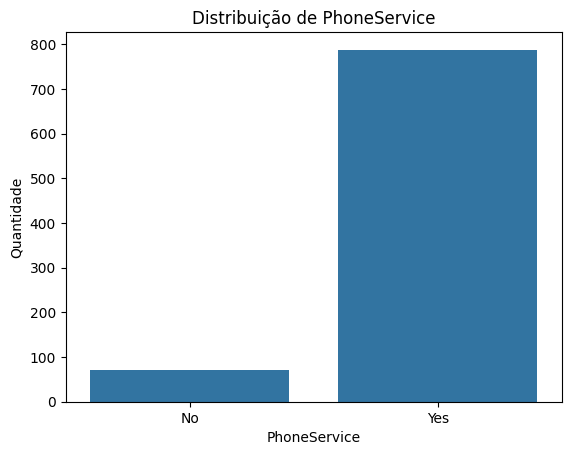

In [210]:
# Ver distribuição da coluna categórica

sns.countplot(x='PhoneService', data=df)

plt.title('Distribuição de PhoneService')
plt.xlabel('PhoneService')
plt.ylabel('Quantidade')

plt.show()

In [211]:
# Ver moda
df['PhoneService'].mode()

0    Yes
Name: PhoneService, dtype: str

In [212]:
# Substituir valores nulos pela moda
df['PhoneService'] = df['PhoneService'].fillna(df['PhoneService'].mode()[0])

In [213]:
df.isnull().sum()

customerID            0
Genero                0
Idoso                 0
Casado                0
Dependents            0
Tempo_como_Cliente    0
PhoneService          0
Servico_Internet      0
Servico_Seguranca     0
Suporte_Tecnico       0
StreamingTV           0
Tipo_Contrato         0
PaymentMethod         0
Pagamento_Mensal      0
Total_Pago            0
Churn                 0
dtype: int64

A coluna PhoneService apresentou grande quantidade de valores faltantes, tornando inadequada a exclusão das linhas, pois isso causaria grande perda de dados na base.

Por se tratar de uma variável categórica, foi utilizada a moda para substituição dos valores nulos, escolhendo a categoria com maior frequência na distribuição dos dados.

Para apoiar a decisão, foi utilizado um gráfico de barras para visualizar a frequência das categorias presentes na coluna.

# 3 - Verifique se encontramos valores digitados incorretamente, ou com letras maiusculas ou minusculas, ou até mesmo mesmos valores porém escritos de forma dirente e corrija.

In [214]:
# Verificar valores únicos das colunas categóricas
colunas_categoricas = df.select_dtypes(include='object').columns

for coluna in colunas_categoricas:
    print(f'\n{coluna}:')
    print(df[coluna].unique())


customerID:
<StringArray>
['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '0895-LMRSF', '8098-LLAZX',
 '8266-VBFQL', '8181-YHCMF', '2240-HSJQD', '1248-DYXUB', '0265-EDXBD',
 ...
 '7641-TQFHN', '1552-TKMXS', '9206-GVPEQ', '8622-ZLFKO', '1596-BBVTG',
 '6188-UXBBR', '2333-KWEWW', '5702-SKUOB', '1134-YWTYF', '6061-GWWAV']
Length: 2175, dtype: str

Genero:
<StringArray>
['Female', 'Male']
Length: 2, dtype: str

Casado:
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

Dependents:
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

PhoneService:
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

Servico_Internet:
<StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

Servico_Seguranca:
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

Suporte_Tecnico:
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

StreamingTV:
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

Tipo_Contrato:
<StringArray>
['Month-to-month', 'One

C:\Users\julia\AppData\Local\Temp\ipykernel_22724\2585402840.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  colunas_categoricas = df.select_dtypes(include='object').columns


In [215]:
# Corrigir valores digitados de formas diferentes

df['Genero'] = df['Genero'].replace({
    'M': 'Male',
    'F': 'Female',
    'f': 'Female'
})

df['Servico_Internet'] = df['Servico_Internet'].replace({
    'dsl': 'DSL'
})

In [216]:
print(df['Genero'].value_counts())
print(df['Servico_Internet'].value_counts())

Genero
Male      1120
Female    1055
Name: count, dtype: int64
Servico_Internet
Fiber optic    983
DSL            726
No             466
Name: count, dtype: int64


Foi realizada a verificação dos valores únicos das colunas categóricas para identificar inconsistências de digitação, diferenças entre letras maiúsculas e minúsculas e categorias escritas de formas diferentes.

Foram identificadas inconsistências na coluna Genero, onde os valores M, F e f representavam as mesmas categorias de Male e Female. Também foi identificada inconsistência na coluna Servico_Internet, em que o valor dsl representava a mesma categoria de DSL.

Esses valores foram padronizados para evitar duplicidade de categorias e garantir maior consistência na análise dos dados.

# [EXTRA] 4 - Caso deseje, para manter um padrão na sua base, renomeie as colunas ou deixando em português, ou inglês.

In [217]:
# Renomeando colunas para manter padrão em inglês

df = df.rename(columns={
    'customerID': 'customer_id',
    'Genero': 'gender',
    'Idoso': 'senior_citizen',
    'Casado': 'married',
    'Dependents': 'dependents',
    'Tempo_como_Cliente': 'tenure',
    'PhoneService': 'phone_service',
    'Servico_Internet': 'internet_service',
    'Servico_Seguranca': 'security_service',
    'Suporte_Tecnico': 'tech_support',
    'StreamingTV': 'streaming_tv',
    'Tipo_Contrato': 'contract_type',
    'PaymentMethod': 'payment_method',
    'Pagamento_Mensal': 'monthly_payment',
    'Total_Pago': 'total_paid',
    'Churn': 'churn'
})

In [218]:
df.columns

Index(['customer_id', 'gender', 'senior_citizen', 'married', 'dependents',
       'tenure', 'phone_service', 'internet_service', 'security_service',
       'tech_support', 'streaming_tv', 'contract_type', 'payment_method',
       'monthly_payment', 'total_paid', 'churn'],
      dtype='str')

Foi realizado o processo de padronização dos nomes das colunas da base de dados, convertendo-as para o idioma inglês e utilizando letras minúsculas com separação por underscore (_).

A padronização facilita a leitura do código, melhora a organização da base e contribui para boas práticas em projetos de análise de dados e ciência de dados.

In [ ]:
df.head(10)

,customer_id,gender,senior_citizen,married,dependents,tenure,phone_service,internet_service,security_service,tech_support,streaming_tv,contract_type,payment_method,monthly_payment,total_paid,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,DSL,No,No,No,Month-to-month,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,DSL,Yes,No,No,One year,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,DSL,Yes,No,No,Month-to-month,Mailed check,53.85,108.15,Yes
300,0895-LMRSF,Male,0,No,No,23,Yes,DSL,No,No,Yes,One year,Bank transfer (automatic),64.90,1509.80,No
301,8098-LLAZX,Female,1,No,No,4,Yes,Fiber optic,No,No,Yes,Month-to-month,Electronic check,95.45,396.10,Yes
302,8266-VBFQL,Male,0,No,No,4,Yes,Fiber optic,No,Yes,No,Month-to-month,Electronic check,90.40,356.65,No
303,8181-YHCMF,Female,0,Yes,Yes,68,Yes,DSL,No,Yes,Yes,Two year,Credit card (automatic),60.30,4109.00,No
304,2240-HSJQD,Male,0,No,Yes,38,Yes,Fiber optic,No,No,No,Month-to-month,Mailed check,81.85,3141.70,No
305,1248-DYXUB,Male,0,Yes,Yes,52,Yes,No,No internet service,No internet service,No internet service,Two year,Mailed check,24.80,1229.10,No
306,0265-EDXBD,Male,1,Yes,No,32,Yes,Fiber optic,No,No,No,Month-to-month,Electronic check,74.90,2303.35,Yes
